In [4]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Read documents
df = pd.read_csv('vgchartz-2024.csv')

In [6]:
# print firsts information
df

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [8]:
df.shape

(64016, 14)

In [9]:

df.sample(5)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
20818,/games/boxart/full_5502101JapanFrontccc.jpg,Giant Robo: The Animation - Chikyuu ga Seishis...,PS2,Action,D3 Publisher,Hikaru-Pro,NaN,NaN,NaN,NaN,NaN,NaN,2004-11-03,NaN
33815,/games/boxart/default.jpg,Dawn of Aces II,PC,Misc,Activision Value,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,2005-12-05,NaN
21695,/games/boxart/full_8720524JapanFrontccc.jpg,Oide Rascal,GB,Action,Seta Corporation,Pinocchio,NaN,NaN,NaN,NaN,NaN,NaN,2001-04-25,NaN
11583,/games/boxart/full_623454AmericaFrontccc.jpg,R.B.I. Baseball 18,PS4,Sports,MLB Advanced Media,MLB Advanced Media,NaN,0.07,0.06,NaN,NaN,0.01,2018-03-20,2018-02-27
52211,/games/boxart/full_7998365JapanFrontccc.jpg,Mobile Suit Gundam Seed Destiny: Rengou vs. Z....,PS2,Shooter,Namco Bandai,Capcom,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-07,NaN


In [10]:
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [27]:
#  Convert data and create a year column 
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

In [28]:
# Replace Nan for 0 so that calculation work correctly
vendas_colunas = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df[vendas_colunas] = df[vendas_colunas].fillna(0)

In [36]:
# Create a new DataFrame file containing only games with a values of total_sales
df_sales = df.dropna(subset=['total_sales'])

print(f"There are {len(df_sales)} games based on sales data.")

There are 64016 games based on sales data.


In [37]:
df['total_sales'] = df['total_sales'].fillna(0)

In [38]:
# Verificar quantos duplicados existem
print(df.duplicated().sum())

0


In [43]:
# Grouped by publisher and totalling the sales of 'other_sales'
top_5_other_sales = df.groupby('publisher')['other_sales'].sum().nlargest(5).reset_index()


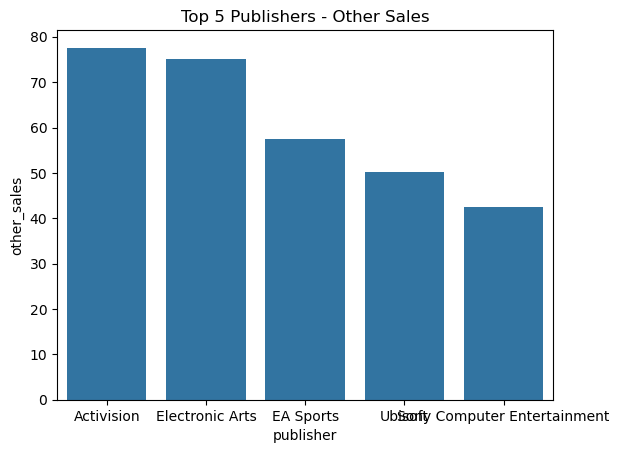

In [42]:
# Plot top 5 Publishers

top_5_pub = df.groupby('publisher')['other_sales'].sum().nlargest(5).reset_index()

sns.barplot(data=top_5_pub, x='publisher', y='other_sales')
plt.title('Top 5 Publishers - Other Sales')
plt.show()

Data Engineering
"I opted to use .fillna(0) on the other_sales column to ensure that null values were not excluded from the analysis. Instead, they are treated as zero sales, preserving the integrity of the total volume of titles per publisher."

Design Decision
"I chose a Bar Chart because it allows for an immediate and clear visual comparison between discrete categories (publishers). I applied the 'magma' palette to create a visual contrast that highlights the sales leaders."

In [44]:
# 1. Preparation of Datas
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# 2. Filter by the requestperiod (2010-2020)
df_q2 = df[(df['year'] >= 2010) & (df['year'] <= 2020)].copy()

# Clean of columns 'na_sales' and 'pal_sales'
df_q2['na_sales'] = df_q2['na_sales'].fillna(0)
df_q2['pal_sales'] = df_q2['pal_sales'].fillna(0)

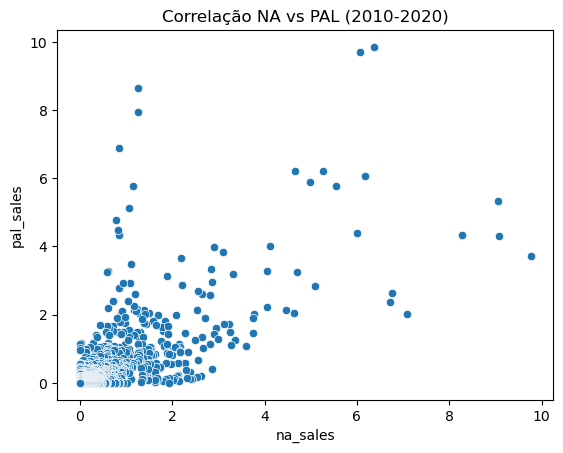

In [45]:
# Agora você só precisa filtrar o período, pois a coluna 'year' já foi criada
df_periodo = df[(df['year'] >= 2010) & (df['year'] <= 2020)]

sns.scatterplot(data=df_periodo, x='na_sales', y='pal_sales')
plt.title('Correlação NA vs PAL (2010-2020)')
plt.show()

 Data Cleaning & Engineering
"To address the correlation between 'pal_sales' and 'na_sales' for titles released between 2010 and 2020, I performed the following steps:

Date Conversion: Transformed the release_date column into a datetime format to accurately extract the launch year.

Filtering: Narrowed the dataset to include only games released within the 2010–2020 timeframe (inclusive).

Handling Missing Values: Similar to the previous task, I filled null values in both na_sales and pal_sales with 0 to ensure all relevant data points were preserved for the correlation analysis."

2. Visualization Choice
"I selected a Scatter Plot to analyze the relationship between the two numerical variables (North American vs. European sales). Since a Bar Chart was utilized for the first question, opting for a scatter plot here satisfies the requirement for visualization diversity while providing the most effective method to identify trends and correlations."